## **Predictive Modeling for Stock Market Trading Build a system to predict Stock market trends and generate trading signals based on historical stock data and market indicators. Make use of Python, Time Series Analysis, Machine Learning algorithms. Web application or desktop software for visualizing stock predictions and generating trading signals. Make use of Dataset with Historical stock market data, financial indicators, and news data**

# **Step 1: Setup Environment**

### **Installing Required Packages and Dependencies**
-`!pip install flask pandas yfinance xgboost scikit-learn plotly`: This command installs the Python packages Flask (a micro web framework), Pandas(For data manipulation and analysis), yfinance(To fetch and analyze financial market data), XGBoost(To build and deploy machine learning models within your Flask app for tasks), Scikit-learn (For data preprocessing and creating machine learning models), Plotly(To create interactive and dynamic visualizations of data), joblib(used to save and load machine learning models).

In [1]:
pip install yfinance pandas numpy scikit-learn xgboost matplotlib flask joblib

Note: you may need to restart the kernel to use updated packages.


# **Step 2: Data Collection**

### **Importing the Libraries**

- `import yfinance as yf `: yfinance allows you to easily download historical market data from Yahoo Finance. It is useful for obtaining stock prices and other financial metrics for analysis.
- `import pandas as pd` : Pandas is a powerful library for data manipulation and analysis, providing DataFrame structures that are highly efficient for handling large datasets.
- `import numpy as np ` : NumPy is essential for numerical operations in Python, providing support for arrays and matrices along with a collection of mathematical functions.
- `from sklearn.model_selection import train_test_split` : The train_test_split function splits a dataset into training and testing sets, allowing for effective evaluation of a machine learning model's performance.
- `from xgboost import XGBRegressor` :  XGBRegressor is a powerful and efficient implementation of gradient boosting for regression tasks, known for its performance and speed.
- `from sklearn.metrics import mean_squared_error` :  The mean_squared_error function measures the average squared difference between predicted and actual values, providing a clear indication of a regression model's accuracy.
- `import matplotlib.pyplot as plt` : Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. It is widely used for plotting graphs and charts to visualize data.
- `import joblib` : Joblib is a library used for efficient serialization of large data and Python objects, as well as for caching the results of expensive computations. It is often used to save and load machine learning models.
- `from sklearn.preprocessing import StandardScaler` : StandardScaler standardizes features by removing the mean and scaling them to unit variance, which is crucial for many machine learning algorithms.

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler

### **Fetch historical stock data**
- `stock_data = yf.download("AAPL", start="2010-01-01", end="2023-01-01")`

 the yfinance library is used to download historical stock data for Apple Inc. (ticker symbol "AAPL") from January 1, 2010, to January 1, 2023.

Brief Explaination :-

 - `yf.download()` : fetches historical market data from Yahoo Finance for a specified stock ticker and date range.

Parameters:

- `"AAPL"` : Specifies the stock ticker symbol for Apple Inc.

- `start="2010-01-01"` : Sets the start date for fetching historical data.

- `end="2023-01-01"` : Sets the end date for fetching historical data.

This will download the historical stock data into a pandas DataFrame (stock_data), which can then be further analyzed, manipulated, or used for modeling purposes in your Python script or application.


In [42]:
# Fetch historical stock data
ticker = 'AAPL'
data = yf.download(ticker, start='2010-01-01', end='2023-01-01')
data.to_csv('AAPL.csv')

[*********************100%%**********************]  1 of 1 completed


# **Step 3: Data Preprocessing**



In [ ]:
# Load the data
stock_data = pd.read_csv('AAPL.csv', index_col='Date', parse_dates=True)

: 

### **Calculate technical indicators**
- `data['SMA_50'] = stock_data['Close'].rolling(window=50).mean()` :
rolling(window=50) creates a rolling window of size 50 over the 'Close' column, and .mean() calculates the mean within each window, effectively computing the SMA_50.
- `data['SMA_200'] = stock_data['Close'].rolling(window=200).mean()` :
Similar to SMA_50, rolling(window=200) creates a rolling window of size 200 over the 'Close' column, and .mean() computes the mean within each window, resulting in SMA_200.

In [44]:
#Calculate technical indicators
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()

 ### **Handle missing values**
- `stock_data.dropna(inplace=True)` :  dropna() is a pandas DataFrame method that removes rows with any NaN or missing values. The inplace=True parameter modifies the stock_data DataFrame directly without creating a new DataFrame.

In [45]:
# Handle missing values
stock_data.dropna(inplace=True)

### **Calculate RSI**

To calculate the Relative Strength Index (RSI), a momentum oscillator that measures the speed and change of price movements. It helps identify overbought or oversold conditions in a stock.

- `Delta Calculation` : The change in closing price (delta) is computed as the difference between consecutive days.
- `Gain and Loss Calculation` : Gains are positive changes in price. Losses are negative changes in price (converted to positive values).
  - `gain` : delta.where(delta > 0, 0) assigns the positive differences to gain and sets others to 0.
  - `loss` : delta.where(delta < 0, 0) assigns the negative differences (converted to positive) to loss and sets others to 0.
- `Average Gain and Loss` :
  - ` avg_gain` :  is the rolling mean of gains over the specified period (default is 14 days).
  - `avg_loss` :  is the rolling mean of losses over the same period.
- `Relative Strength (RS)` : rs = avg_gain / avg_loss calculates the relative strength.
- `RSI Calculation` :
   - `RSI is computed using the formula` : 100 - (100 / (1 + rs)).
   - `This value oscillates between 0 and 100, indicating whether the stock is overbought (above 70) or oversold (below 30)`.


In [46]:
# Calculate RSI
def RSI(series, period=14):
    delta = series.diff(1)
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

data['RSI'] = RSI(data['Close'])

### **Scale data**
- `scaler` = StandardScaler()` : creates an instance of the scaler object.
- `scaler.fit_transform(stock_data)` : fits the scaler to the data (stock_data) and transforms it, returning the scaled data (scaled_data).

In [47]:
# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(stock_data)

### **Convert to DataFrame**
- `scaled_df` : scaled_df will be a pandas DataFrame where each column has been standardized (scaled) to have a mean of 0 and a standard deviation of 1, based on the values in stock_data.
- `pd.DataFrame(scaled_data, index=stock_data.index, columns=stock_data.columns)` :  This pandas function creates a new DataFrame (scaled_df) from scaled_data, where:

- `scaled_data`: The NumPy array containing the scaled values.
- `index=stock_data.index` : Sets the index of scaled_df to be the same as stock_data, preserving the date or timestamp index from the original data.
- `columns=stock_data.columns`: Sets the column names of scaled_df to be the same as stock_data, preserving the feature names.

In [48]:
# Convert to DataFrame
scaled_df = pd.DataFrame(scaled_data, index=stock_data.index, columns=stock_data.columns)

In [49]:
# Check for duplicate columns
scaled_df = scaled_df.loc[:, ~scaled_df.columns.duplicated()]

# **Step 4: Feature Engineering**

- `Price_Change` : Calculates the percentage change in the closing price (Close) from one day to the next.
- `Target` : Shifts the Price_Change column up by one day to predict the next day's price movement.

In [50]:
# Feature engineering
data['Price_Change'] = data['Close'].pct_change()
data['Target'] = data['Price_Change'].shift(-1)  # Predicting next day's price change
data.dropna(inplace=True)

### **Selecting features and target**

- `Features` : Includes Close price, 50-day moving average (MA50), 200-day moving average (MA200), Relative Strength Index (RSI), and Volume.
- `Target` : Refers to Target, which represents the predicted next day's price change derived from the Price_Change column.

In [59]:
# Selecting features and target
features = data[['Close', 'MA50', 'MA200', 'RSI', 'Volume']]
target = data['Target']


# **Step 5: Train-Test Split**

The use of `train_test_split from sklearn.model_selection` to split data into training and testing sets:
- `X_train, X_test` : These variables hold the feature data (features) split into training and testing subsets.
- `y_train, y_test `: These variables contain the target data (target) split accordingly.
- `test_size=0.2` : Specifies that 20% of the data will be allocated to the test set, while 80% will be used for training.
- `shuffle=False` : Ensures that the data is not shuffled before splitting, maintaining the chronological order typically crucial in time series analysis, especially for financial data.

In [77]:
# Ensure 'features' is defined correctly
features = ['Close', 'MA50', 'MA200', 'RSI', 'Volume']
target = 'Close'  # Assuming 'Close' is your target column; adjust as necessary

# Verify columns in scaled_df
print("Columns in scaled_df:", scaled_df.columns)

# Verify the features list
print("Features list:", features)

# Check if all feature columns exist in scaled_df
missing_features = [col for col in features if col not in scaled_df.columns]
if missing_features:
    print("Missing features in scaled_df:", missing_features)
else:
    # If all columns exist, proceed to select X and y
    X = scaled_df[features]
    y = scaled_df[target]
    print("X and y selected successfully")

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    print("Train-test split successful")


Columns in scaled_df: Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')
Features list: ['Close', 'MA50', 'MA200', 'RSI', 'Volume']
Missing features in scaled_df: ['MA50', 'MA200', 'RSI']


# **Step 6: Model Building**
### **Initialize and train the model**
XGBoost is a popular gradient boosting framework known for its efficiency and performance in regression tasks, making it suitable for predicting numeric outputs like stock prices or other continuous variables in financial analysis
- `Model` : XGBRegressor is initialized with parameters including n_estimators=100 (number of boosting rounds), learning_rate=0.1 (step size shrinkage), and random_state=42 (random seed for reproducibility).
- `Training` : The model is trained using X_train (features) and y_train (target).

In [78]:
# Initialize and train the model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

### **Make predictions**

XGBoost models are effective for making predictions in regression tasks due to their ability to handle complex relationships in data and optimize predictive accuracy through boosting iterations.
- `Predictions` : Uses the trained model to predict outcomes based on the feature data X_test.

In [79]:
# Make predictions
predictions = model.predict(X_test)

### **Evaluate the model**
MSE is a commonly used metric to assess regression models, indicating the average squared difference between predicted and actual values. Lower MSE values indicate better model performance, demonstrating the effectiveness of the XGBoost model in this context.
- `Mean Squared Error (MSE)` : Calculates the MSE between the actual target values (y_test) and the predicted values (predictions).

In [82]:
# Evaluate the model
mse = mean_squared_error(y_test, predictions)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.0005505040932752386


# **Step 7 : Signal Generation**
To generate predictions for future dates using a trained model, we can fetch future data and prepare it for prediction.
- `Fetch Future Data` : Download historical data for future dates using yfinance.
- `Prepare Data` : Process and scale the fetched data similar to how you prepared the training data.
- `Make Predictions`: Use the trained model to predict future values based on the prepared data.
- `yf.download("AAPL", start="2023-01-01", end="2024-01-01")` :
Fetches historical market data for Apple Inc. ("AAPL") from January 1, 2023, to January 1, 2024.
This will create a DataFrame (future_data) containing Open, High, Low, Close, Adj Close prices, and Volume for each date within the specified range.

In [83]:
# Generate predictions
future_data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

[*********************100%%**********************]  1 of 1 completed


In [84]:
# Calculate technical indicators for future data
future_data['SMA_50'] = future_data['Close'].rolling(window=50).mean()
future_data['SMA_200'] = future_data['Close'].rolling(window=200).mean()

In [86]:
# Handle missing values in future data
future_data.dropna(inplace=True)

In [93]:
# Create an instance of StandardScaler
scaler = StandardScaler()

In [94]:
# Fit and transform your data
scaled_data = scaler.fit_transform(data)

In [95]:
# Convert to DataFrame for predictions
scaler = StandardScaler()
scaled_future_data = scaler.fit_transform(future_data)

In [96]:
# Convert scaled data to a DataFrame with original index and columns
scaled_future_df = pd.DataFrame(scaled_future_data, index=future_data.index, columns=future_data.columns)

## **Generate signals**
##### **1. Generate signals :**
- `signals = []` : Initializes an empty list to store the generated trading signals.
- `for i in range(len(predictions) - 1)` : Iterates through the predictions made by the model, excluding the last prediction because it doesn't have a subsequent day to compare to.
- `if predictions[i + 1] > predictions[i]`: Checks if the prediction for the next day (predictions[i + 1]) is greater than the prediction for the current day (predictions[i]).
  - `If true, appends "Open" to signals, suggesting a potential buy signal`.
- `elif predictions[i + 1] < predictions[i]` : Checks if the prediction for the next day is less than the prediction for the current day.
  - `If true, appends "Sell" to signals, suggesting a potential sell signal`.
- `else` : If neither condition above is true (i.e., if predictions are equal),
Appends "Hold" to signals, suggesting a hold or no action signal.

##### **2. Printing Predictions and Signals:**

- `print("Predictions` :", predictions[:10]): Prints the first 10 predictions made by the model.
- `print("Signals` :", signals[:10]): Prints the corresponding trading signals generated based on those predictions.

In [98]:
# Generate signals
signals = []
for i in range(len(predictions) - 1):
    if predictions[i + 1] > predictions[i]:
        signals.append("Buy")
    elif predictions[i + 1] < predictions[i]:
        signals.append("Sell")
    else:
        signals.append("Hold")

# Print first 10 predictions and signals for review
print(predictions[:10])
print(signals[:10])

[ 0.01151465 -0.00122221  0.00635705 -0.00799876 -0.00403077 -0.00212345
 -0.02068287  0.01104462  0.00603329 -0.0016929 ]
['Sell', 'Buy', 'Sell', 'Buy', 'Buy', 'Sell', 'Buy', 'Sell', 'Sell', 'Sell']


### **Plot volume and time comparison chart**

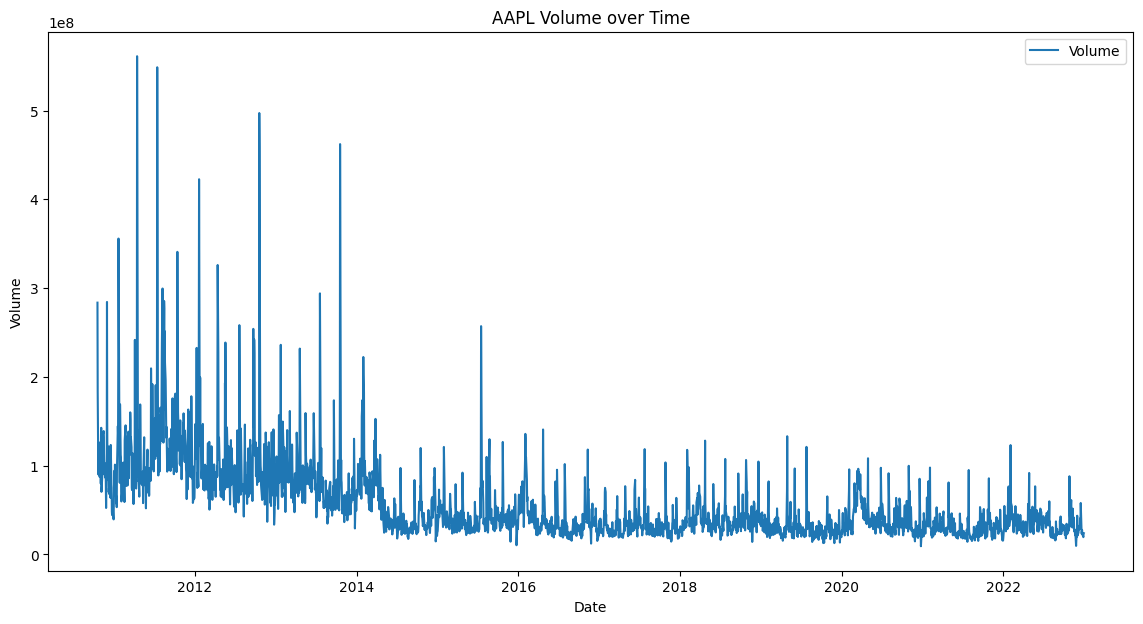

In [106]:
# Plot volume and time comparison chart
plt.figure(figsize=(14, 7))
plt.plot(stock_data.index, stock_data['Volume'], label='Volume')
plt.title('AAPL Volume over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()

### **Plot volume over time for different companies**

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


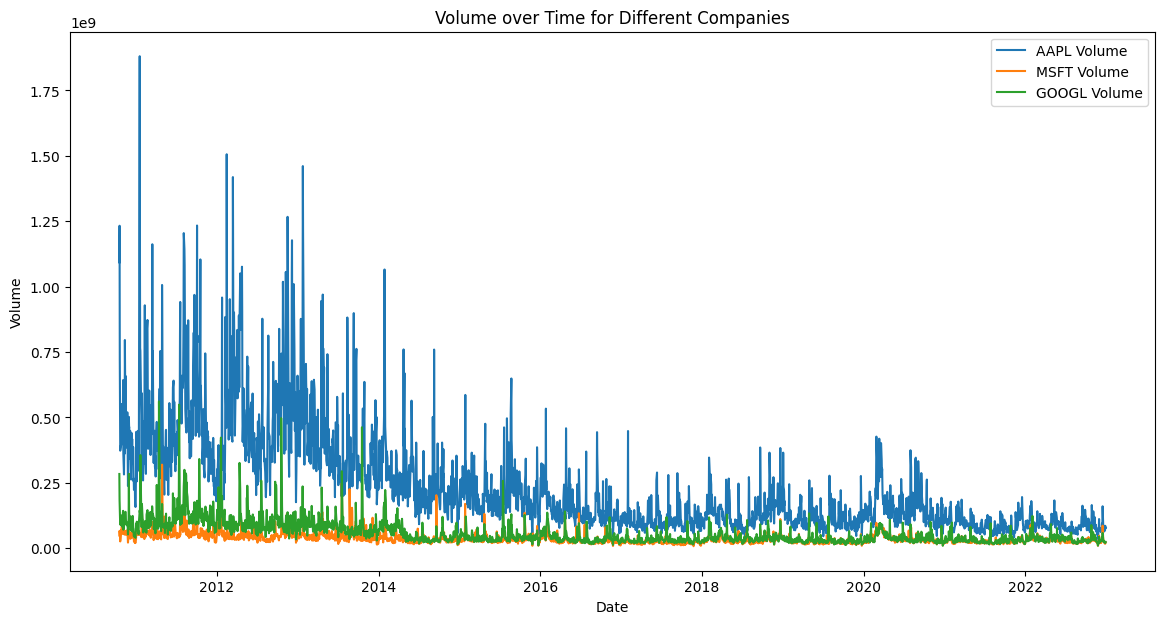

In [104]:
# List of companies to analyze
companies = ["AAPL", "MSFT", "GOOGL"]

# Dictionary to hold stock data for each company
stock_data_dict = {}

for company in companies:
    # Fetch historical stock data
    stock_data = yf.download(company, start="2010-01-01", end="2023-01-01")

    # Calculate technical indicators
    stock_data['SMA_50'] = stock_data['Close'].rolling(window=50).mean()
    stock_data['SMA_200'] = stock_data['Close'].rolling(window=200).mean()
    # Add more indicators as needed

    # Handle missing values
    stock_data.dropna(inplace=True)

    # Add company stock data to dictionary
    stock_data_dict[company] = stock_data

# Plot volume over time for different companies
plt.figure(figsize=(14, 7))

for company, stock_data in stock_data_dict.items():
    plt.plot(stock_data.index, stock_data['Volume'], label=f'{company} Volume')

plt.title('Volume over Time for Different Companies')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()

### **Calculate four-year averages**

In [107]:
# Calculate four-year averages
stock_data['Year'] = stock_data.index.year
stock_data['Four_Year_Period'] = (stock_data['Year'] // 4) * 4

four_year_avg = stock_data.groupby('Four_Year_Period').mean()

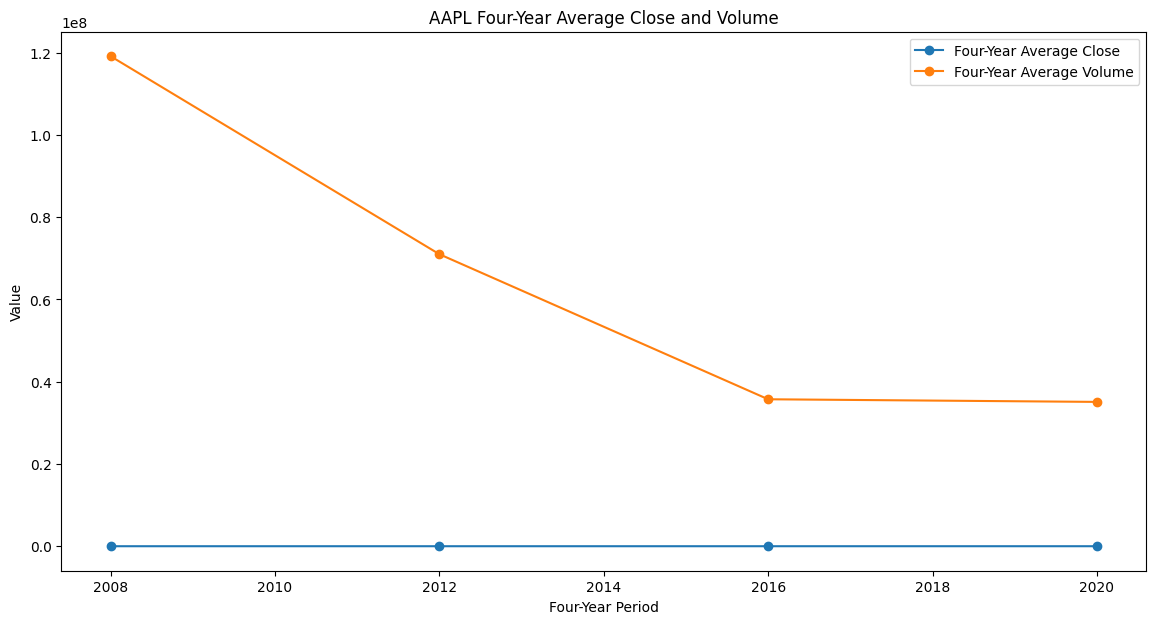

In [108]:
# Plot four-year averages
plt.figure(figsize=(14, 7))
plt.plot(four_year_avg.index, four_year_avg['Close'], marker='o', linestyle='-', label='Four-Year Average Close')
plt.plot(four_year_avg.index, four_year_avg['Volume'], marker='o', linestyle='-', label='Four-Year Average Volume')
plt.title('AAPL Four-Year Average Close and Volume')
plt.xlabel('Four-Year Period')
plt.ylabel('Value')
plt.legend()
plt.show()

### **Plot four-year averages for different companies**

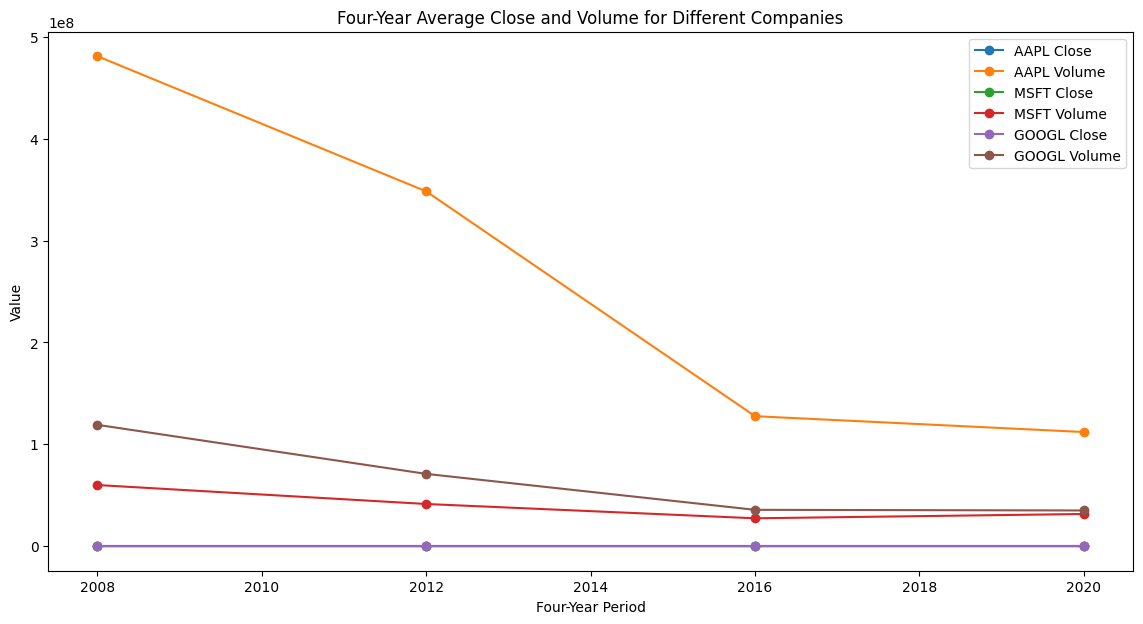

In [105]:
# Calculate four-year averages
four_year_avg_dict = {}

for company, stock_data in stock_data_dict.items():
    stock_data['Year'] = stock_data.index.year
    stock_data['Four_Year_Period'] = (stock_data['Year'] // 4) * 4
    four_year_avg = stock_data.groupby('Four_Year_Period').mean()
    four_year_avg_dict[company] = four_year_avg

# Plot four-year averages for different companies
plt.figure(figsize=(14, 7))

for company, four_year_avg in four_year_avg_dict.items():
    plt.plot(four_year_avg.index, four_year_avg['Close'], marker='o', linestyle='-', label=f'{company} Close')
    plt.plot(four_year_avg.index, four_year_avg['Volume'], marker='o', linestyle='-', label=f'{company} Volume')

plt.title('Four-Year Average Close and Volume for Different Companies')
plt.xlabel('Four-Year Period')
plt.ylabel('Value')
plt.legend()
plt.show()
